In [205]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [206]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [207]:
df.shape

(5110, 12)

In [208]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [209]:
df.drop(columns='id',inplace=True)

In [210]:
df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [211]:
df['stroke'].value_counts(normalize=True)

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

In [212]:
df['bmi']=df['bmi'].fillna(round(df['bmi'].mean(),2))

In [213]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.89,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1


<Axes: xlabel='stroke', ylabel='age'>

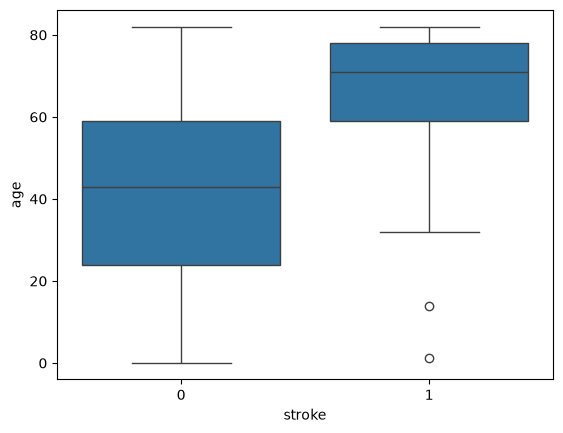

In [214]:
sns.boxplot(data=df, x=df['stroke'],y=df['age'])

<Axes: xlabel='stroke', ylabel='avg_glucose_level'>

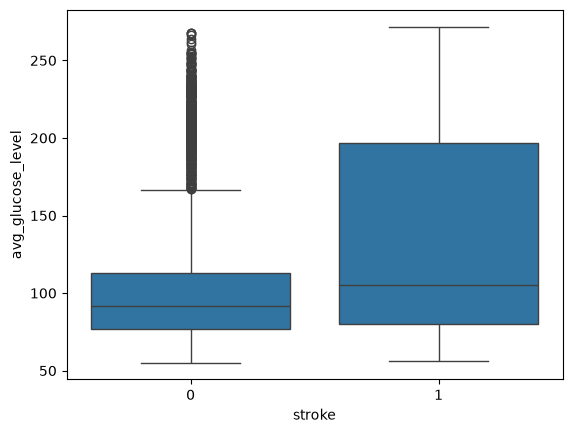

In [215]:
sns.boxplot(data=df,x=df['stroke'], y=df['avg_glucose_level'])

<Axes: xlabel='stroke', ylabel='bmi'>

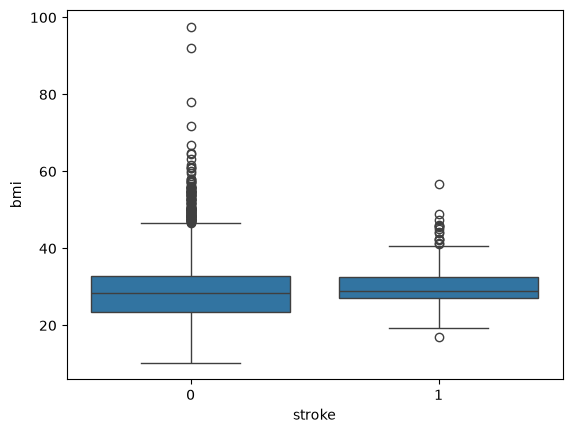

In [216]:
sns.boxplot(data=df,x=df['stroke'], y=df['bmi'])

<Axes: xlabel='gender', ylabel='count'>

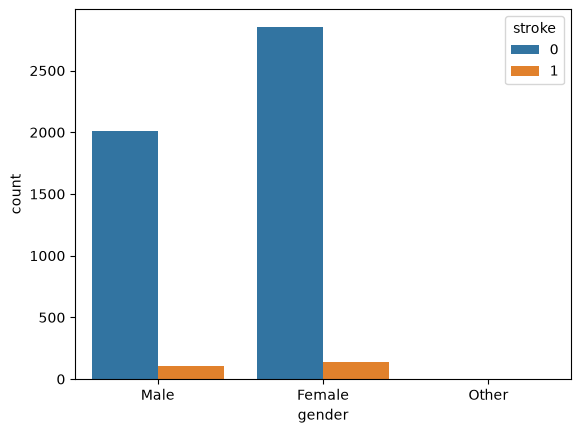

In [217]:
sns.countplot(data=df,x=df['gender'], hue=df['stroke'])

In [218]:
df = df[df['gender'] != 'Other'].copy()

In [219]:
label_cols = [
    'gender',
    'ever_married',
    'Residence_type'
]

onehot_cols = [
    'work_type',
    'smoking_status'
]

numeric_cols = [
    'age',
    'avg_glucose_level',
    'bmi'
]

binary_cols = [
    'hypertension',
    'heart_disease'
]

In [220]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

In [221]:
df=pd.get_dummies(df,columns=onehot_cols,dtype=int)

In [222]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,Male,67.0,0,1,Yes,Urban,228.69,36.60,1,0,0,1,0,0,0,1,0,0
1,Female,61.0,0,0,Yes,Rural,202.21,28.89,1,0,0,0,1,0,0,0,1,0
2,Male,80.0,0,1,Yes,Rural,105.92,32.50,1,0,0,1,0,0,0,0,1,0
3,Female,49.0,0,0,Yes,Urban,171.23,34.40,1,0,0,1,0,0,0,0,0,1
4,Female,79.0,1,0,Yes,Rural,174.12,24.00,1,0,0,0,1,0,0,0,1,0


In [223]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in label_cols:
    df[col]=le.fit_transform(df[col])

In [224]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.60,1,0,0,1,0,0,0,1,0,0
1,0,61.0,0,0,1,0,202.21,28.89,1,0,0,0,1,0,0,0,1,0
2,1,80.0,0,1,1,0,105.92,32.50,1,0,0,1,0,0,0,0,1,0
3,0,49.0,0,0,1,1,171.23,34.40,1,0,0,1,0,0,0,0,0,1
4,0,79.0,1,0,1,0,174.12,24.00,1,0,0,0,1,0,0,0,1,0


In [225]:
X=df.drop(columns=['stroke'])
y=df['stroke']

In [226]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [227]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=scaler.transform(X_test[numeric_cols])

In [228]:
X_train

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
845,0,0.209397,0,0,1,1,-0.821221,0.545268,0,0,1,0,0,0,0,1,0
3745,0,-0.629845,0,0,0,1,-0.485884,-0.993166,0,0,1,0,0,0,0,1,0
4184,0,-0.364822,0,0,1,0,0.302317,-0.773390,0,0,1,0,0,0,0,1,0
3410,1,-0.232310,0,0,1,0,0.062342,0.493556,0,0,1,0,0,0,0,1,0
284,1,-1.292405,0,0,0,1,-0.527297,0.351348,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1434,0,0.076885,0,0,1,1,-0.291800,0.803828,0,0,1,0,0,0,1,0,0
461,0,-1.204064,0,0,0,0,0.169570,-1.212943,0,0,0,0,1,1,0,0,0
1052,0,0.783615,0,0,1,0,-0.609900,0.946037,0,0,1,0,0,0,1,0,0
1757,1,-0.541504,0,0,1,1,-0.712875,-0.372621,0,0,1,0,0,1,0,0,0


In [229]:
from sklearn.utils.class_weight import compute_class_weight
weights=compute_class_weight('balanced',classes=np.unique(y_train), y=y_train)
class_weight_dict={0:weights[0],1:weights[1]}
print(class_weight_dict)

{0: np.float64(0.5255915637860082), 1: np.float64(10.268844221105528)}


In [230]:
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense,Input,Dropout

model_ann=Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')])

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=[
    keras.metrics.Recall(name='recall'),
    keras.metrics.Precision(name='precision')
])


In [231]:
model_ann.fit(X_train,y_train,validation_split=0.2,batch_size=64,epochs=100,verbose=1, class_weight=class_weight_dict)

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.6599 - precision: 0.0721 - recall: 0.3092 - val_loss: 0.4967 - val_precision: 0.1593 - val_recall: 0.3830
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5757 - precision: 0.1144 - recall: 0.5658 - val_loss: 0.4631 - val_precision: 0.1336 - val_recall: 0.8298
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5161 - precision: 0.1131 - recall: 0.7895 - val_loss: 0.4236 - val_precision: 0.1456 - val_recall: 0.8085
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4720 - precision: 0.1212 - recall: 0.8487 - val_loss: 0.3985 - val_precision: 0.1579 - val_recall: 0.7660
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4972 - precision: 0.1172 - recall: 0.9013 - val_loss: 0.4340 - val_precision: 0.1423 - val_recall: 0.8085
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4881 - precision: 0.1166 - recall: 0.9079 - val_loss: 0.4436 - val_precision: 0.1397 - val_recall:

In [232]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

y_pred_prob=model_ann.predict(X_test).ravel()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [233]:
y_pred=(y_pred_prob>0.5).astype(int)

In [234]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85       972
           1       0.12      0.68      0.21        50

    accuracy                           0.75      1022
   macro avg       0.55      0.72      0.53      1022
weighted avg       0.94      0.75      0.82      1022



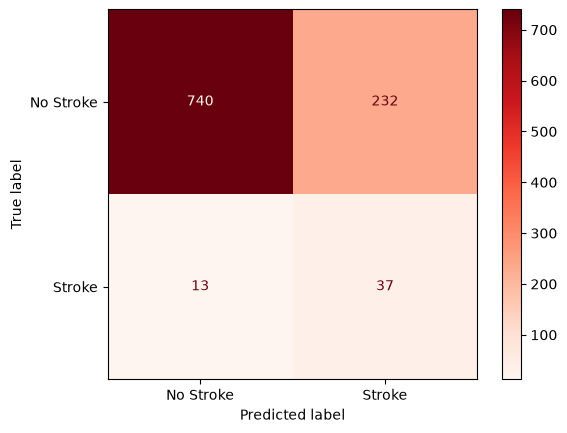

In [235]:
ConfusionMatrixDisplay(
    cm,
    display_labels=['No Stroke', 'Stroke']
).plot(cmap='Reds')

In [236]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in np.arange(0.1, 0.91, 0.05):
    y_pred = (y_pred_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.10 | Precision: 0.11 | Recall: 0.82 | F1: 0.20
Threshold: 0.15 | Precision: 0.11 | Recall: 0.80 | F1: 0.20
Threshold: 0.20 | Precision: 0.12 | Recall: 0.80 | F1: 0.21
Threshold: 0.25 | Precision: 0.12 | Recall: 0.80 | F1: 0.21
Threshold: 0.30 | Precision: 0.12 | Recall: 0.76 | F1: 0.21
Threshold: 0.35 | Precision: 0.12 | Recall: 0.74 | F1: 0.21
Threshold: 0.40 | Precision: 0.12 | Recall: 0.72 | F1: 0.21
Threshold: 0.45 | Precision: 0.12 | Recall: 0.70 | F1: 0.21
Threshold: 0.50 | Precision: 0.12 | Recall: 0.68 | F1: 0.21
Threshold: 0.55 | Precision: 0.13 | Recall: 0.68 | F1: 0.21
Threshold: 0.60 | Precision: 0.13 | Recall: 0.68 | F1: 0.22
Threshold: 0.65 | Precision: 0.13 | Recall: 0.68 | F1: 0.22
Threshold: 0.70 | Precision: 0.14 | Recall: 0.64 | F1: 0.22
Threshold: 0.75 | Precision: 0.15 | Recall: 0.56 | F1: 0.24
Threshold: 0.80 | Precision: 0.15 | Recall: 0.34 | F1: 0.21
Threshold: 0.85 | Precision: 0.15 | Recall: 0.14 | F1: 0.15
Threshold: 0.90 | Precision: 0.24 | Reca

In [237]:
import joblib

# Save trained ANN model
model_ann.save("model.keras")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature/column order
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']